In [7]:
import os
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler


def ridge_closed_form(X_train, Y_train, lam):
    n_features = X_train.shape[1]
    I = np.eye(n_features, dtype=X_train.dtype)
    A = X_train.T @ X_train + lam * I
    b = X_train.T @ Y_train
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ b


def ridge_regression_fast(X_train, Y_train, X_eval, Y_eval, lam):
    # Add bias term
    X_train_b = np.hstack((X_train, np.ones((X_train.shape[0], 1), dtype=X_train.dtype)))
    X_eval_b  = np.hstack((X_eval,  np.ones((X_eval.shape[0], 1), dtype=X_eval.dtype)))

    # Train ridge regression
    W = ridge_closed_form(X_train_b, Y_train, lam)

    # Handle 1D vs 2D labels
    y_train_true = Y_train if Y_train.ndim == 1 else np.argmax(Y_train, axis=1)
    y_eval_true  = Y_eval  if Y_eval.ndim == 1  else np.argmax(Y_eval, axis=1)

    # Predictions
    y_train_pred = X_train_b @ W
    y_train_hats = np.argmax(y_train_pred, axis=1)
    train_accuracy = np.mean(y_train_hats == y_train_true)

    y_eval_pred = X_eval_b @ W
    y_eval_hats = np.argmax(y_eval_pred, axis=1)

    accuracy  = accuracy_score(y_eval_true, y_eval_hats)
    precision = precision_score(y_eval_true, y_eval_hats, average='macro', zero_division=0)
    recall    = recall_score(y_eval_true, y_eval_hats, average='macro', zero_division=0)
    f1        = f1_score(y_eval_true, y_eval_hats, average='macro', zero_division=0)

    results = np.array([lam, train_accuracy, accuracy, precision, recall, f1], dtype=np.float64)

    return results

In [13]:
if __name__ == "__main__":
    a_value = 0.9
    u_dc_value = 1.0
    mu = 1.0
    lambda_values = np.array([1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4])
    top_k_values = [61, 62, 63, 64, 66, 67, 68, 69, 81, 82, 83, 84, 86, 87, 88, 89]
    full_f_values = np.load("/content/top-sens.npy")

    # labels
    labels_train = np.load(f"/content/label_matrix_train.npy")
    labels_val   = np.load(f"/content/label_matrix_val.npy")
    lebels_test  = np.load(f"/content/label_matrix_test.npy")

    # Results dir
    results_dir = f"/content/results"
    os.makedirs(results_dir, exist_ok=True)


    full_results = []
    for top_k in top_k_values:
        f_values = full_f_values[:int(top_k)]
        f_values = np.sort(f_values)

        state_matrix = np.zeros((10910, len(f_values) * 60))

        for i, f in enumerate(f_values):
            cols = np.load(f"/content/f-{int(f)}.npz")["arr_0"]
            state_matrix[:, i*60:(i+1)*60] = cols

        X_train = state_matrix[:len(labels_train)]
        X_val   = state_matrix[len(labels_train): len(labels_train) + len(labels_val)]
        X_test  = state_matrix[len(labels_train) + len(labels_val): ]

        # Standardize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)
        X_test  = scaler.transform(X_test)

        best_val_acc = -np.inf
        best_lambda  = None
        best_results = None

        for lam in lambda_values:
            results = ridge_regression_fast(
                X_train, labels_train,
                X_val, labels_val,
                lam
            )

            val_acc = results[2]
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_lambda  = lam
                best_results = results

        # Save per-top-k best
        np.savetxt(
            f"{results_dir}/results-a-{a_value:.2f}-u_dc-{u_dc_value:.2f}-topk-{top_k}.txt",
            best_results.reshape(1, -1),
            fmt="%.6f"
        )

        full_results.append({
            "top_k": top_k,
            "lambda": best_lambda,
            "val_acc": best_val_acc
        })


    best_entry = max(full_results, key=lambda x: x["val_acc"])

    best_top_k   = best_entry["top_k"]
    best_lambda  = best_entry["lambda"]

    print(f"Best validation result:")
    print(f"  top_k   = {best_top_k}")
    print(f"  lambda  = {best_lambda}")
    print(f"  val_acc = {best_entry['val_acc']:.5f}")

    f_values = full_f_values[:best_top_k]
    f_values = np.sort(f_values)

    state_matrix = np.zeros((10910, len(f_values) * 60))

    for i, f in enumerate(f_values):
        cols = np.load(f"/content/f-{int(f)}.npz")["arr_0"]
        state_matrix[:, i*60:(i+1)*60] = cols

    X_train = state_matrix[:len(labels_train)]
    X_val   = state_matrix[len(labels_train): len(labels_train) + len(labels_val)]
    X_test  = state_matrix[len(labels_train) + len(labels_val): ]

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)


    results = ridge_regression_fast(
        X_train, labels_train,
        X_test, lebels_test,
        best_lambda
    )

    print("\nTest set results with best configuration:")
    print(
        f"Lambda: {results[0]:.5f}, "
        f"Train Acc: {results[1]:.5f}, "
        f"Test Acc: {results[2]:.5f}, "
        f"Precision: {results[3]:.5f}, "
        f"Recall: {results[4]:.5f}, "
        f"F1: {results[5]:.5f}"
    )

Best validation result:
  top_k   = 89
  lambda  = 10.0
  val_acc = 0.86822

Test set results with best configuration:
Lambda: 10.00000, Train Acc: 0.98002, Test Acc: 0.48000, Precision: 0.51655, Recall: 0.48000, F1: 0.44941


Highest val accuracy: 86.5842 at top-k = 85


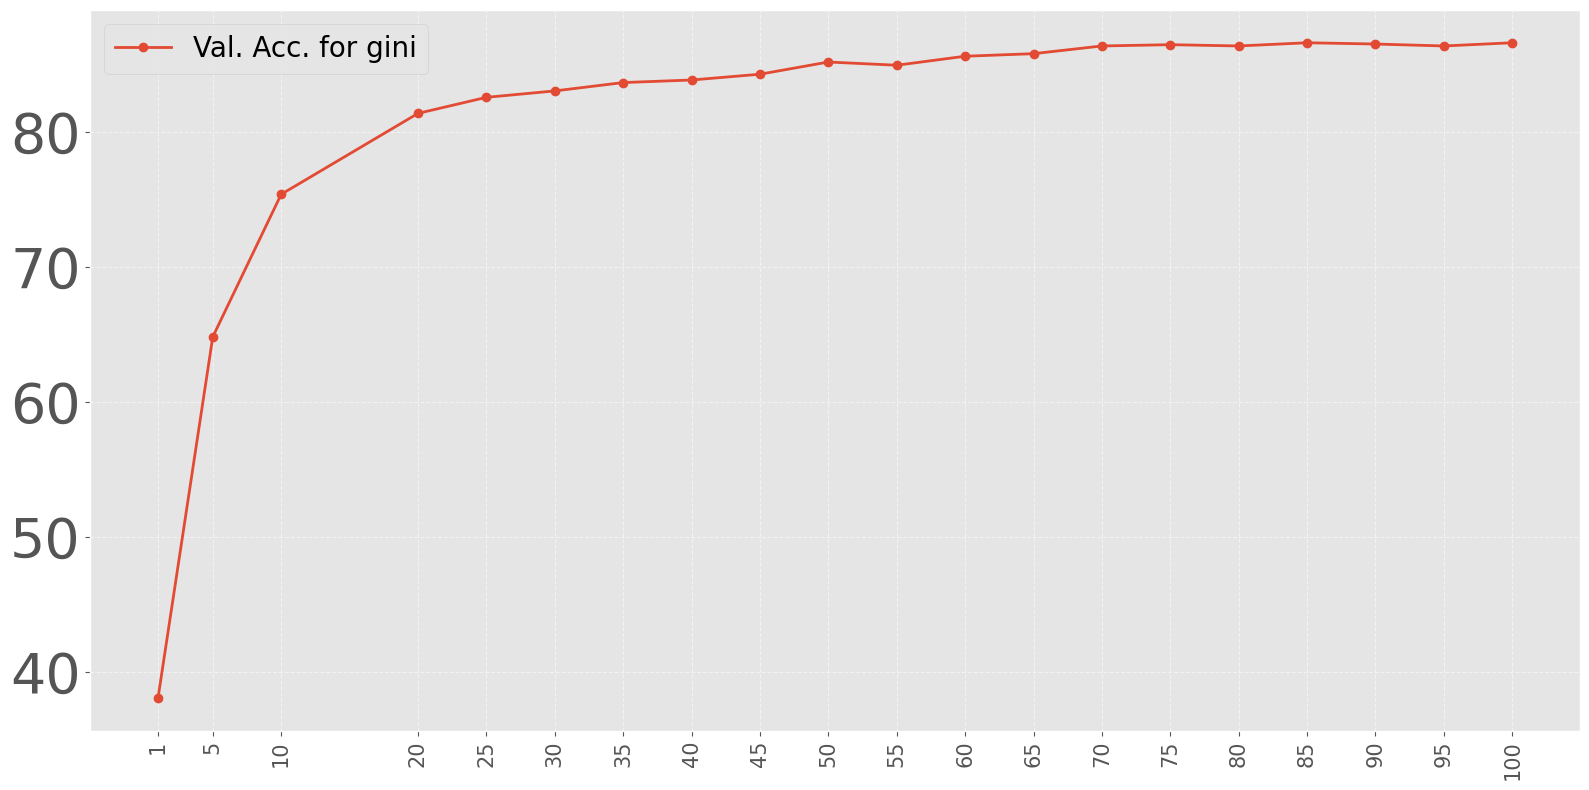

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
plt.style.use("ggplot")

# Parameters
a_value = 0.9
u_dc_value = 1.0
top_k_values = [1, 5, 10, 20, 25, 30, 35, 40, 45, 50, 55, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 75, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 95, 100]

# Plotting
plt.figure(figsize=(16, 8))

# Initialize data storage
test_accuracies = []

# Extract accuracy data for lambda = 1e4
for top_k in top_k_values:
    try:
        data = np.loadtxt(f"/content/results/results-a-{a_value:.2f}-u_dc-{u_dc_value:.2f}-topk-{top_k}.txt")
        test_accuracy = data[2] * 100  # Convert to percentage
        test_accuracies.append(test_accuracy)

    except Exception as e:
        test_accuracies.append(np.nan)


# print highst test accuracy
print(f"Highest val accuracy: {np.nanmax(test_accuracies)} at top-k = {top_k_values[np.nanargmax(test_accuracies)]}")

# save accuracies
np.save(f"val-acc-topk-sens-lambda-opt.npy", test_accuracies)

# Plot test accuracy in **black**
plt.plot(top_k_values, test_accuracies, marker='o', linewidth=2, label=f"Val. Acc. for gini")

# Customize the plot
# plt.xscale('log')  # Log scale for nodes
plt.grid(True, linestyle='--', alpha=0.5)
# plt.legend(loc='best', fontsize=20)
plt.xticks(top_k_values, labels=[f'{n}' for n in top_k_values], rotation=90, fontsize=15)
plt.yticks(fontsize=40)
plt.tight_layout()
plt.legend(fontsize=20)

# Save the figure
# plt.savefig(f"accuracy_vs_topk.png", bbox_inches='tight')
# plt.savefig(f"accuracy_vs_topk-lambda-opt.png", bbox_inches='tight')
# plt.close()
plt.show()

Highest val accuracy: 86.8221 at top-k = 89


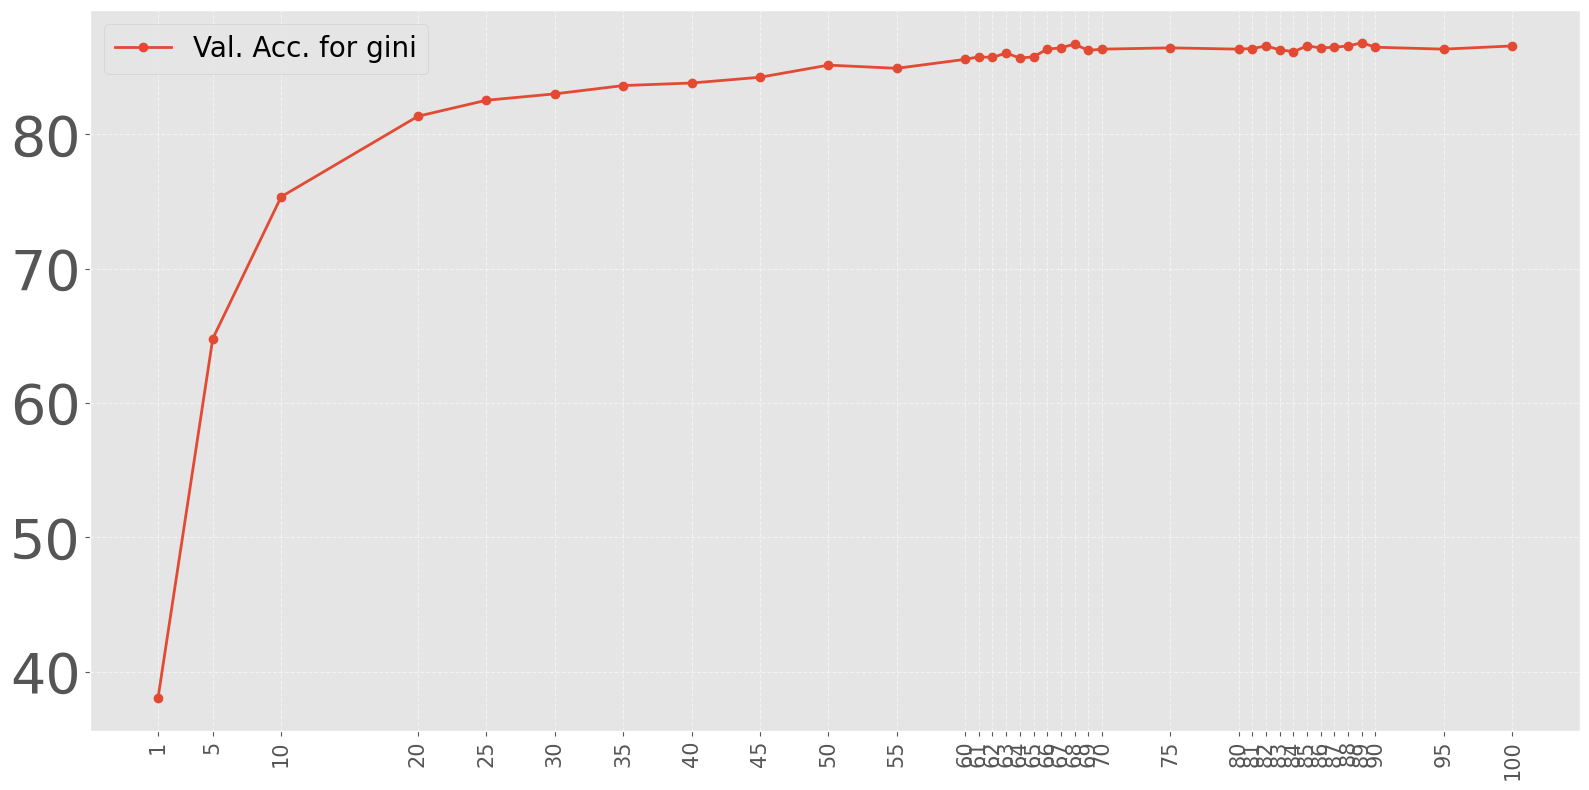

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
plt.style.use("ggplot")

# Parameters
a_value = 0.9
u_dc_value = 1.0
top_k_values = [1, 5, 10, 20, 25, 30, 35, 40, 45, 50, 55, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 75, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 95, 100]

# Plotting
plt.figure(figsize=(16, 8))

# Initialize data storage
test_accuracies = []

# Extract accuracy data for lambda = 1e4
for top_k in top_k_values:
    try:
        data = np.loadtxt(f"/content/results/results-a-{a_value:.2f}-u_dc-{u_dc_value:.2f}-topk-{top_k}.txt")
        test_accuracy = data[2] * 100  # Convert to percentage
        test_accuracies.append(test_accuracy)

    except Exception as e:
        test_accuracies.append(np.nan)


# print highst test accuracy
print(f"Highest val accuracy: {np.nanmax(test_accuracies)} at top-k = {top_k_values[np.nanargmax(test_accuracies)]}")

# save accuracies
np.save(f"val-acc-topk-sens-lambda-opt.npy", test_accuracies)

# Plot test accuracy in **black**
plt.plot(top_k_values, test_accuracies, marker='o', linewidth=2, label=f"Val. Acc. for gini")

# Customize the plot
# plt.xscale('log')  # Log scale for nodes
plt.grid(True, linestyle='--', alpha=0.5)
# plt.legend(loc='best', fontsize=20)
plt.xticks(top_k_values, labels=[f'{n}' for n in top_k_values], rotation=90, fontsize=15)
plt.yticks(fontsize=40)
plt.tight_layout()
plt.legend(fontsize=20)

# Save the figure
# plt.savefig(f"accuracy_vs_topk.png", bbox_inches='tight')
# plt.savefig(f"accuracy_vs_topk-lambda-opt.png", bbox_inches='tight')
# plt.close()
plt.show()